# Test Distance Pipeline

In this notebook, we will focus on what might be going wrong while calculating distance between predicted and ground truth landmark in milimeters (mm). 

## A. Random Landmark Prediction

To do so, 

1) I will get a random prediction and save as landmark - in order to eliminate training and its complications. 

2) Then I calculate distance in coordinates and milimeters the same way.

3) Upload landmark and random prediction to 3DSlicer. 

4) Measure in coordinates and pixels. Do they match?

If they match, we move on trial B.

## B. Test Landmark Extraction

In this section, 

1) I generate a random probabilistic heatmap,

2) Get argmax of this heatmap,

3) Save as landmark coordinates.

4) Continue on A.2.

In [12]:
import numpy as np
import pandas as pd
import torch
import os
import nrrd

def extract_image(filename):
    """Extract the image into a 3D numpy array [x, y, z]. As it was saved in RAS

    Args:
      filename: Path and name of nifti file.

    Returns:
      data: A 3D numpy array [x, y, z]
      pix_dim: pixel spacings

    """

    data, header = nrrd.read(filename)

    if len(data.shape) == 4:
        data=data[:, :, :, 0]

    return data, header


def create_gaussian_heatmap(coord, template, alpha = 3, eps=1e-6, **args):

    """
    Compute the Gaussian distribution value based on distance from a landmark.

    Args:
    coord : array-like
        Landmark coordinates, i.e., the mean of the Gaussian.
    template : np.ndarray volume that corresponds to this gaussian heatmap. 
    alpha : float
        Coefficient controlling the spread of the Gaussian.

    Returns:
    heatmap : a 3D matrix same shape as _template.shape_
        Gaussian value at pixel x relative to the landmark.
    """
    # Convert from torch to numpy array.
    coord = coord.numpy()
    # Unpack the input dimensions
    D, H, W = template.shape
    # Create a grid of all possible (d, h, w) pixel coordinates
    # d_range: [0, 1, ..., D-1]
    # h_range: [0, 1, ..., H-1]
    # w_range: [0, 1, ..., W-1]
    d_range = np.arange(D)
    h_range = np.arange(H)
    w_range = np.arange(W)
    
    # Use np.meshgrid to create a coordinate grid for the entire heatmap
    # d_grid, h_grid, w_grid each have shape (D, H, W) and represent all possible coordinates in 3D space
    d_grid, h_grid, w_grid = np.meshgrid(d_range, h_range, w_range, indexing='ij')
    # Calculate the squared Euclidean distance for every coordinate in the grid relative to the landmark
    distance = np.sqrt((d_grid - coord[0])**2 + (h_grid - coord[1])**2 + (w_grid - coord[2])**2)
    
    heatmap = np.exp(-distance / (2 * alpha**2)) 

    # Clip very low values
    heatmap[heatmap < eps] = 0

    # Find indices where `template` is 0 and set corresponding heatmap values to 0
    heatmap[template == 0] = 0

    return heatmap

lmk = 'prn'
sys_root = '/media/yusuf/HDD 4TB/Rotated/Processed/'
dataframe = pd.read_csv(sys_root + 'sinfo__fold0__.csv')

alpha = 3
eps = 1e-6
i = 10

# Load 3D volume
image_path = os.path.join(sys_root, dataframe.loc[i, 'processed__vol_path'])
volume, header = extract_image(image_path)

# Load landmark file
landmark_path = os.path.join(sys_root, dataframe.loc[i, 'processed__csv_path'])
landmark_df = pd.read_csv(landmark_path)

# Extract coordinates for the selected landmark
landmark_row = landmark_df[landmark_df['label'] == lmk]
if landmark_row.empty:
    raise ValueError(f"Landmark '{lmk}' not found in {landmark_path}")

coord = landmark_row[['x', 'y', 'z']].iloc[0].tolist()  # Convert to list
coord = coord / header['spacings'][:3]
coord_tensor = torch.abs(torch.tensor(coord, dtype=torch.float32)) 

# Generate target heatmap

target = create_gaussian_heatmap(coord_tensor, volume, alpha=alpha, eps=eps)
targets = torch.tensor(target).unsqueeze(0)  # Add channel dimension

print(f"Processed {os.path.join(sys_root, 'casos_mar', dataframe.loc[i, 'processed__vol_path'])}")
# Save target

outputs = torch.rand_like(targets)

spacings =  [header['spacings'][:3]]

print(targets.shape, outputs.shape, spacings)

Processed /media/yusuf/HDD 4TB/Rotated/Processed/casos_mar/Casos Mar/volumes/1-29s-06.nrrd
torch.Size([1, 128, 128, 128]) torch.Size([1, 128, 128, 128]) [array([1.6, 1.6, 1.6])]


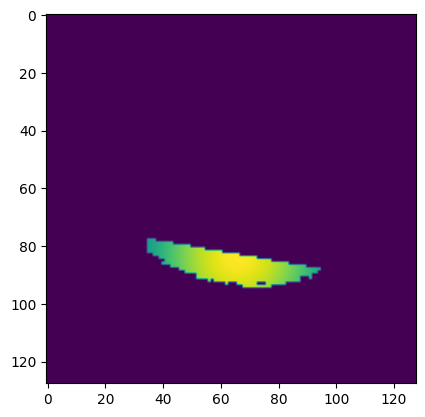

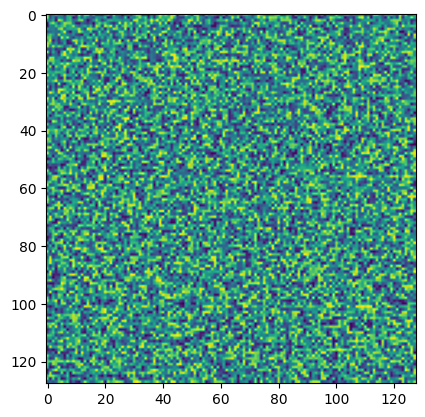

In [8]:
import matplotlib.pyplot as plt

plt.imshow(targets[0, 100])
plt.figure()
plt.imshow(outputs[0, 100])

In [9]:
import torch

def get_peak_location(heatmap, method):
    """Extracts peak location from a heatmap."""
    if method == 'argmax':
        peak = torch.nonzero(heatmap == heatmap.max(), as_tuple=False).float()
        return peak[0] if peak.numel() > 0 else None


def d_mean_mm(outputs, targets, spacings, method='argmax'):
    """
    Computes the mean Euclidean distance (d_mean) between predicted and ground truth landmarks in mm.
    
    Assumption: Only one landmark is present in the heatmap.

    Args:
    - outputs (torch.Tensor): Predicted landmark heatmap, shape (N, D, H, W).
    - targets (torch.Tensor): Ground truth landmark heatmap, shape (N, D, H, W).
    - spacings (list or torch.Tensor): Voxel size in mm [spacing_D, spacing_H, spacing_W].
    - method (str): Peak detection method. 
        - 'com' (center of mass) (recommended for better accuracy).
        - 'argmax' (hard max location).

    Returns:
    - torch.Tensor: Mean distance in mm over batch.
    """

    all_distances = []
    N, D, H, W = outputs.shape  # One landmark only

    for i in range(N):  # Iterate over batch
        pred_peak = get_peak_location(outputs[i], method)
        gt_peak = get_peak_location(targets[i], method)

        if pred_peak is not None and gt_peak is not None:
            pred_peak *= torch.tensor(spacings[i][0], device=pred_peak.device)
            gt_peak *= torch.tensor(spacings[i][0], device=gt_peak.device)

            distance = torch.norm(pred_peak - gt_peak)
            all_distances.append(distance)

    return torch.tensor(all_distances).mean()


outputs_landmark = get_peak_location(outputs[0], method='argmax')
targets_landmark = get_peak_location(targets[0], method='argmax')

outputs_landmark_mm = outputs_landmark * torch.tensor(spacings[0][0]) # assuming iso
targets_landmark_mm = targets_landmark * torch.tensor(spacings[0][0])

distance = torch.norm(outputs_landmark_mm - targets_landmark_mm)

print("Landmarks in voxel: ", outputs_landmark, targets_landmark)
print("Landmarks in mm: ", outputs_landmark_mm, targets_landmark_mm)

print("Distance in mm: ", distance)
print("Does it match with 3D slicer? ")



Landmarks in voxel:  tensor([20., 17., 16.]) tensor([60., 83., 66.])
Landmarks in mm:  tensor([32.0000, 27.2000, 25.6000]) tensor([ 96.0000, 132.8000, 105.6000])
Distance in mm:  tensor(147.1304)
Does it match with 3D slicer? 


In [13]:
template_header = extract_image('/home/yusuf/Source/fetusnet/templates/template.nrrd')[1]
name = 'tmp'
nrrd.write(os.path.join('.', f"{name}.nrrd"), outputs[0].cpu().numpy(), header=template_header)

template_header = extract_image('/home/yusuf/Source/fetusnet/templates/template.nrrd')[1]
name = 'target'
nrrd.write(os.path.join('.', f"{name}.nrrd"), targets[0].cpu().numpy(), header=template_header)

After applying this code in 3D Slicer for both target and output (random tensor) -- I have found that target is saved sucessfully and its landmarks found correctly. However, output no!

```import numpy as np
import slicer
import vtk

for scan in ['30-26s-13', '30-26s-24', '30-26s-26']:
    # Get the active volume node
    volumeNode = slicer.util.getNode(scan)  # Replace with actual volume name

    # Get voxel array
    imageData = slicer.util.arrayFromVolume(volumeNode)

    # Find the max intensity and its coordinates
    max_value = np.max(imageData)
    max_index = np.unravel_index(np.argmax(imageData), imageData.shape)

    # Convert to RAS (World Coordinates)
    ijkToRASMatrix = vtk.vtkMatrix4x4()
    volumeNode.GetIJKToRASMatrix(ijkToRASMatrix)
    ijk_coords = list(max_index)[::-1] + [1]  # Reverse order from NumPy (KJI -> IJK)
    ras_coords = [0, 0, 0, 0]
    ijkToRASMatrix.MultiplyPoint(ijk_coords, ras_coords)

    # Extract RAS coordinates
    ras_x, ras_y, ras_z = ras_coords[:3]

    # Create a Markup Fiducial at the RAS coordinates
    fiducialNode = slicer.mrmlScene.AddNewNodeByClass("vtkMRMLMarkupsFiducialNode", f"pred{scan}")
    fiducialNode.AddFiducial(ras_x, ras_y, ras_z)

    # Print results
    print(f"Max Intensity: {max_value}")
    print(f"Voxel Index (IJK): {max_index}")
    print(f"World Coordinates (RAS): {ras_x}, {ras_y}, {ras_z}")
    print("Fiducial created at max intensity location.")
```


This returned followings for target and output, respectively. 


```Max Intensity: 0.9646855970032552
Voxel Index (IJK): (66, 83, 60)
World Coordinates (RAS): -96.0, -132.8, 105.60000000000001
Fiducial created at max intensity location.
```


```Max Intensity: 0.9999980943204844
Voxel Index (IJK): (28, 53, 124)
World Coordinates (RAS): -198.4, -84.80000000000001, 44.800000000000004
Fiducial created at max intensity location.
```

Suspecting this is due to random properties of output tensor, I will create a heatmap on a, say, **shifted** coordinate.

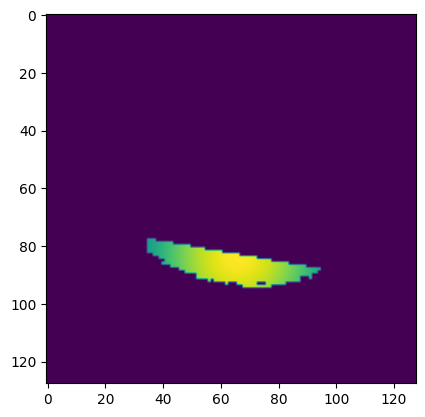

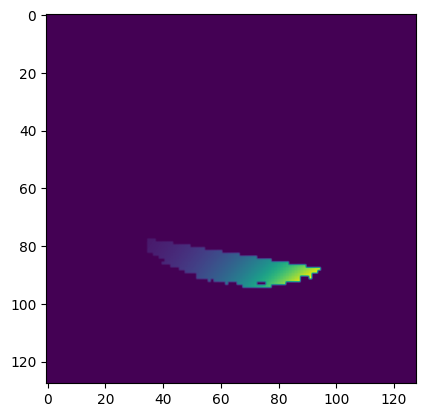

In [17]:
coord_shifted = landmark_row[['x', 'y', 'z']].iloc[0].tolist() # Convert to list
coord_shifted = coord_shifted / header['spacings'][:3] + 50
coord_tensor_shifted = torch.abs(torch.tensor(coord_shifted, dtype=torch.float32)) 

# Generate target heatmap

target_shifted = create_gaussian_heatmap(coord_tensor_shifted, volume, alpha=alpha, eps=eps)
outputs_v2 = torch.tensor(target_shifted).unsqueeze(0)  # Add channel dimension

plt.imshow(targets[0, 100])
plt.figure()
plt.imshow(outputs_v2[0, 100])

In [18]:
outputs_landmark = get_peak_location(outputs[0], method='argmax')
targets_landmark = get_peak_location(targets[0], method='argmax')

outputs_landmark_mm = outputs_landmark * torch.tensor(spacings[0][0]) # assuming iso
targets_landmark_mm = targets_landmark * torch.tensor(spacings[0][0])

distance = torch.norm(outputs_landmark_mm - targets_landmark_mm)

print("Landmarks in voxel: ", outputs_landmark, targets_landmark)
print("Landmarks in mm: ", outputs_landmark_mm, targets_landmark_mm)

print("Distance in mm: ", distance)
print("Does it match with 3D slicer? ")


Landmarks in voxel:  tensor([124.,  53.,  28.]) tensor([60., 83., 66.])
Landmarks in mm:  tensor([198.4000,  84.8000,  44.8000]) tensor([ 96.0000, 132.8000, 105.6000])
Distance in mm:  tensor(128.3994)
Does it match with 3D slicer? 


In [ ]:
template_header = extract_image('/home/yusuf/Source/fetusnet/templates/template.nrrd')[1]
name = 'tmp_v2'
nrrd.write(os.path.join('.', f"{name}.nrrd"), outputs_v2[0].cpu().numpy(), header=template_header)


```Max Intensity: 0.9646855970032552
Voxel Index (IJK): (66, 83, 60)
World Coordinates (RAS): -96.0, -132.8, 105.60000000000001
Fiducial created at max intensity location.
```

```Max Intensity: 0.9999980943204844
Voxel Index (IJK): (28, 53, 124)
World Coordinates (RAS): -198.4, -84.80000000000001, 44.800000000000004
Fiducial created at max intensity location.
```


Yes! It matches! Then, this eliminates:

- Problem is not the way I measure distance.
- Problem is not the way I save volumes.
- Problem is not the way I generate heatmaps.
- Problem might be the random properties of predicted heatmaps (multiple maximums).


## C. Test model prediction

In this section, 

1) I get a prediction from model,

2) Get argmax of this heatmap,

3) Save as landmark coordinates.

4) Continue on A.2.

We select the same test patient

In [22]:
i = 31
# Load 3D volume
image_path = os.path.join(sys_root, dataframe.loc[i, 'processed__vol_path'])
print(image_path)
volume, header = extract_image(image_path)

# Load landmark file
landmark_path = os.path.join(sys_root, dataframe.loc[i, 'processed__csv_path'])
landmark_df = pd.read_csv(landmark_path)

# Extract coordinates for the selected landmark
landmark_row = landmark_df[landmark_df['label'] == lmk]
if landmark_row.empty:
    raise ValueError(f"Landmark '{lmk}' not found in {landmark_path}")

coord = landmark_row[['x', 'y', 'z']].iloc[0].tolist()  # Convert to list
coord = coord / header['spacings'][:3]
coord_tensor = torch.abs(torch.tensor(coord, dtype=torch.float32)) 

# Generate target heatmap

target = create_gaussian_heatmap(coord_tensor, volume, alpha=alpha, eps=eps)
targets = torch.tensor(target).unsqueeze(0)  # Add channel dimension

print(f"Processed {os.path.join(sys_root, 'casos_mar', dataframe.loc[i, 'processed__vol_path'])}")
# Save target
# After running: python fetusnet.py test --use_wandb --ep 100 --wandbpro fetusnetv1 --run_name pixelwise_mse_test_f1 --num_workers 3 --lr 0.0001 --test_patients 17 --model_dir pixelwise_mse_f12025-02-25_23-27-41

output, _ = extract_image('/home/yusuf/Source/fetusnet/runs/pixelwise_mse_test_f12025-03-07_16-39-49/17-20s-04.nrrd')
outputs = torch.tensor(output).unsqueeze(0)  # Add channel dimension

spacings =  [header['spacings'][:3]]

print(targets.shape, outputs.shape, spacings)

/media/yusuf/HDD 4TB/Rotated/Processed/Casos Mar/volumes/17-20s-04.nrrd
Processed /media/yusuf/HDD 4TB/Rotated/Processed/casos_mar/Casos Mar/volumes/17-20s-04.nrrd
torch.Size([1, 128, 128, 128]) torch.Size([1, 128, 128, 128]) [array([1.6, 1.6, 1.6])]


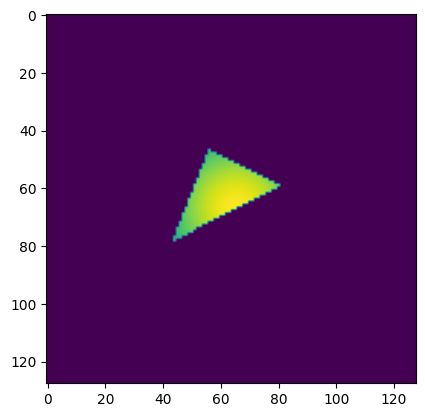

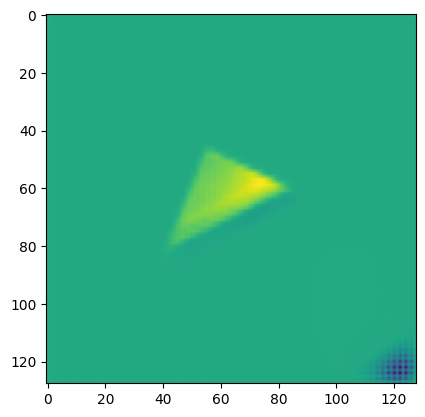

In [24]:
plt.imshow(targets[0, 100])
plt.figure()
plt.imshow(outputs[0, 100])

In [25]:
outputs_landmark = get_peak_location(outputs[0], method='argmax')
targets_landmark = get_peak_location(targets[0], method='argmax')

outputs_landmark_mm = outputs_landmark * torch.tensor(spacings[0][0]) # assuming iso
targets_landmark_mm = targets_landmark * torch.tensor(spacings[0][0])

distance = torch.norm(outputs_landmark_mm - targets_landmark_mm)

print("Landmarks in voxel: ", outputs_landmark, targets_landmark)
print("Landmarks in mm: ", outputs_landmark_mm, targets_landmark_mm)

print("Distance in mm: ", distance)
print("Does it match with 3D slicer? ")


Landmarks in voxel:  tensor([89., 80., 91.]) tensor([69., 67., 65.])
Landmarks in mm:  tensor([142.4000, 128.0000, 145.6000]) tensor([110.4000, 107.2000, 104.0000])
Distance in mm:  tensor(56.4553)
Does it match with 3D slicer? 


Also does it match with d-mean reflected in wandb ? I will print the computed d-means on the air and re run test.

```
In voxels
tensor([89., 80., 91.]) tensor([87., 90., 89.])
In mm
tensor([142.4000, 128.0000, 145.6000]) tensor([139.2000, 144.0000, 142.4000]) [1.6 1.6 1.6]
Distance :  tensor(16.6277)
```


Turns out, target landmark is not retrieved correctly!

In [26]:
template_header = extract_image('/home/yusuf/Source/fetusnet/templates/template.nrrd')[1]
name = 'output_17'
nrrd.write(os.path.join('.', f"{name}.nrrd"), outputs[0].cpu().numpy(), header=template_header)

template_header = extract_image('/home/yusuf/Source/fetusnet/templates/template.nrrd')[1]
name = 'target_17'
nrrd.write(os.path.join('.', f"{name}.nrrd"), targets[0].cpu().numpy(), header=template_header)

```
Max Intensity: 0.15625932812690735
Voxel Index (IJK): (91, 80, 89)
World Coordinates (RAS): -142.4, -128.0, 145.6
Fiducial created at max intensity location.


Max Intensity: 0.9709883782741586
Voxel Index (IJK): (65, 67, 69)
World Coordinates (RAS): -110.4, -107.2, 104.0
Fiducial created at max intensity location.
```


So, it is only in d_mean_mm function during air!

Let's see what we do during air:

1. We transform the **image only** using tio.rescale

```
# Define transformations for 3D images
transforms = [tio.RescaleIntensity((0, 1))] if params.rescale else [] # In this version, only for input image.
transformations = tio.Compose(transforms)
```

2. We convert to tio.subject using
```
...
    image=self.transformations(tio.ScalarImage(tensor=image_tensor)),  # Apply transformations
...
```


In [39]:
import torchio as tio

# Define transformations for 3D images
# transforms = [tio.RescaleIntensity((0, 1))] # In this version, only for input image.
# transformations = tio.Compose(transforms)

targets_transformed = tio.ScalarImage(tensor=targets)
targets_transformed.data.shape

torch.Size([1, 128, 128, 128])

In [40]:
outputs_landmark = get_peak_location(outputs[0], method='argmax')
targets_transformed_landmark = get_peak_location(targets_transformed.data[0], method='argmax')

outputs_landmark_mm = outputs_landmark * torch.tensor(spacings[0][0]) # assuming iso
targets_transformed_landmark_mm = targets_transformed_landmark * torch.tensor(spacings[0][0])

distance = torch.norm(outputs_landmark_mm - targets_transformed_landmark_mm)

print("Landmarks in voxel: ", outputs_landmark, targets_transformed_landmark)
print("Landmarks in mm: ", outputs_landmark_mm, targets_transformed_landmark_mm)

print("Distance in mm: ", distance)
print("Does it match?")

Landmarks in voxel:  tensor([89., 80., 91.]) tensor([69., 67., 65.])
Landmarks in mm:  tensor([142.4000, 128.0000, 145.6000]) tensor([110.4000, 107.2000, 104.0000])
Distance in mm:  tensor(56.4553)
Does it match?


Plus, if I print in infer.py the batch coordinates I get...

> print(batch['coord_x'], batch['coord_y'], batch['coord_z'])

> tensor([109.9439]) tensor([106.9141]) tensor([104.6551])

Okay, problem solved. I wasn't generating targets corrclty in my dataset class!